# Tutorial

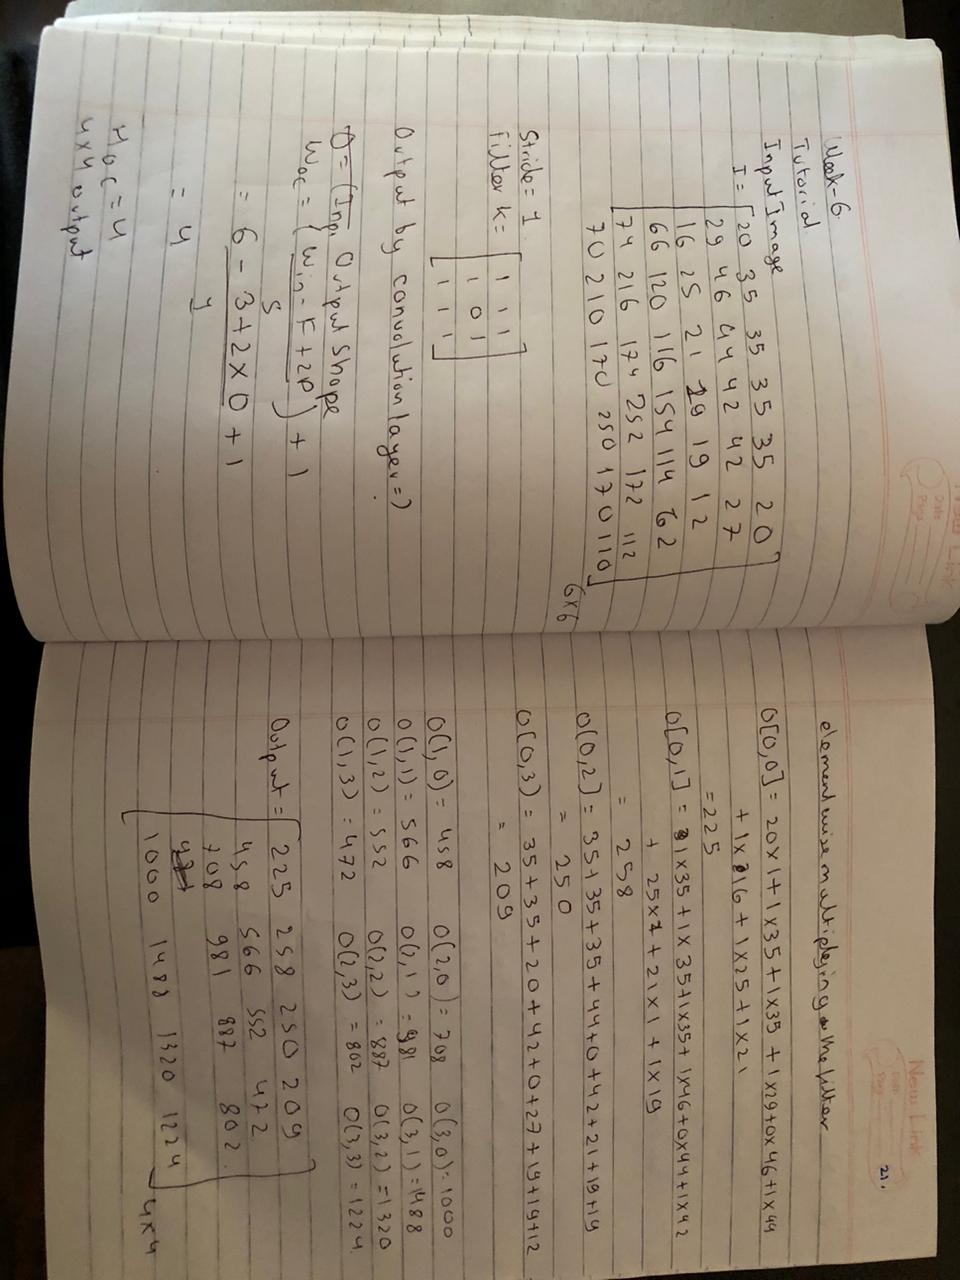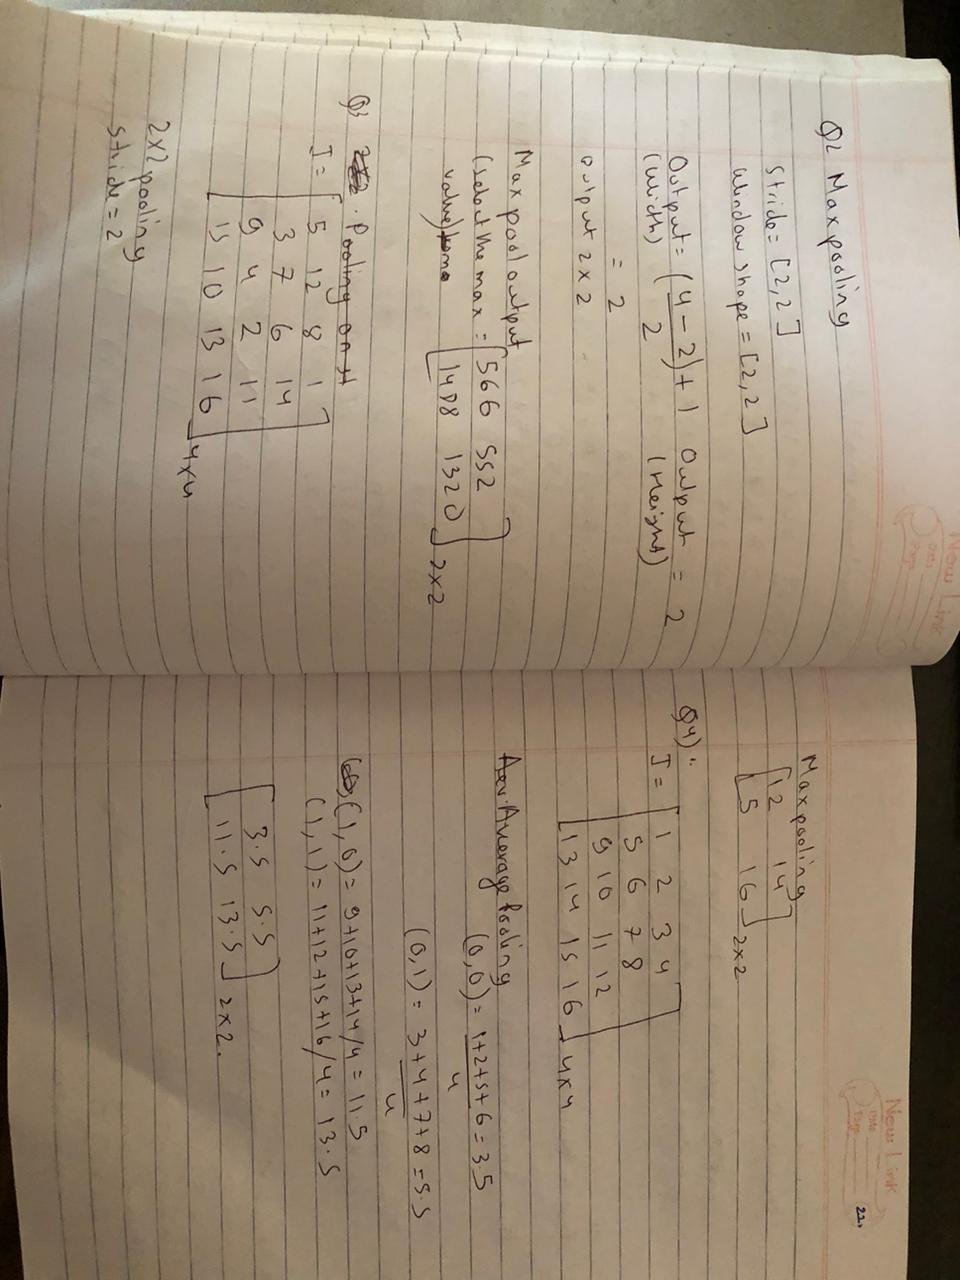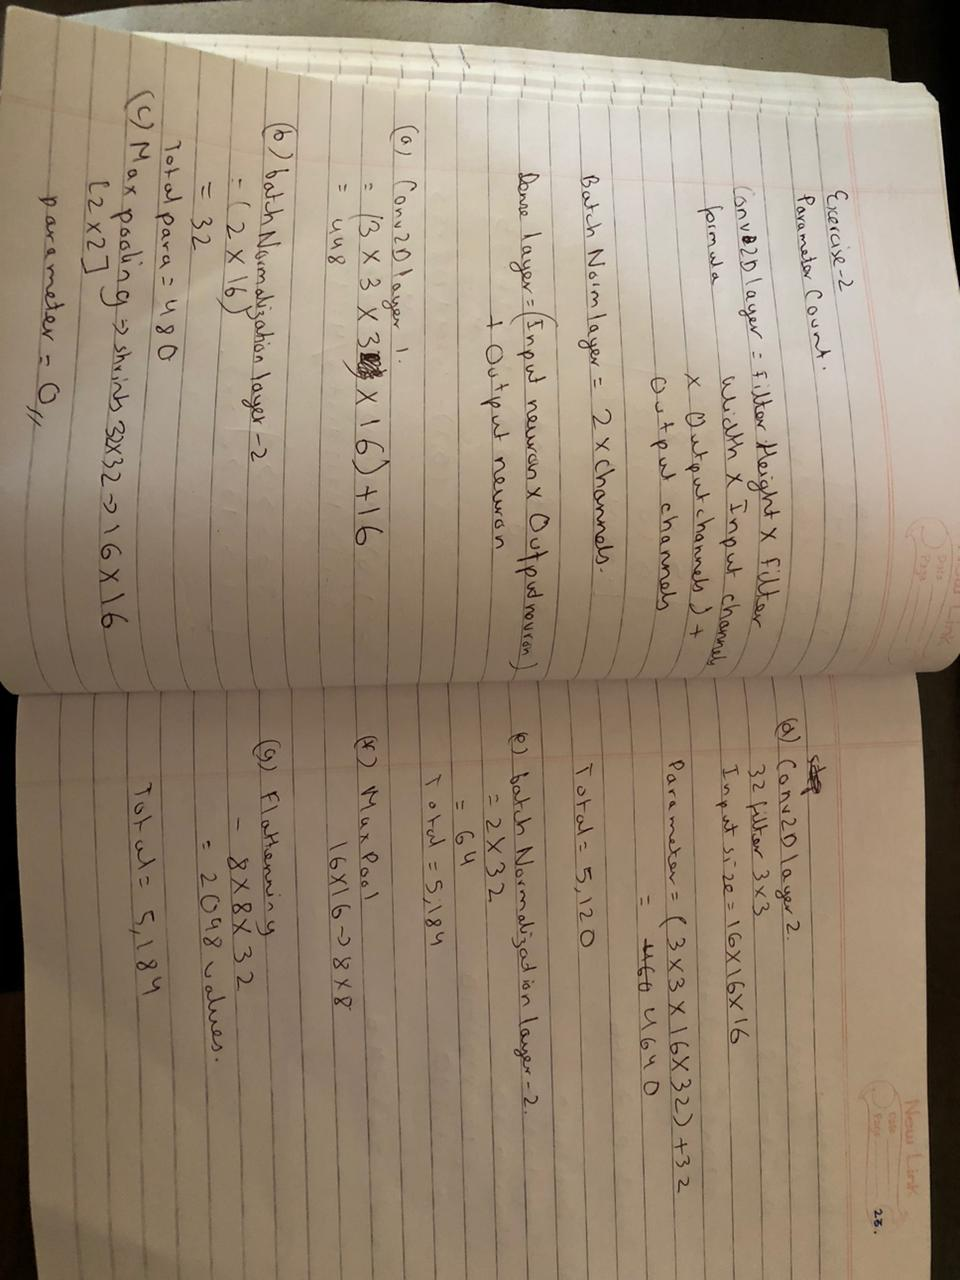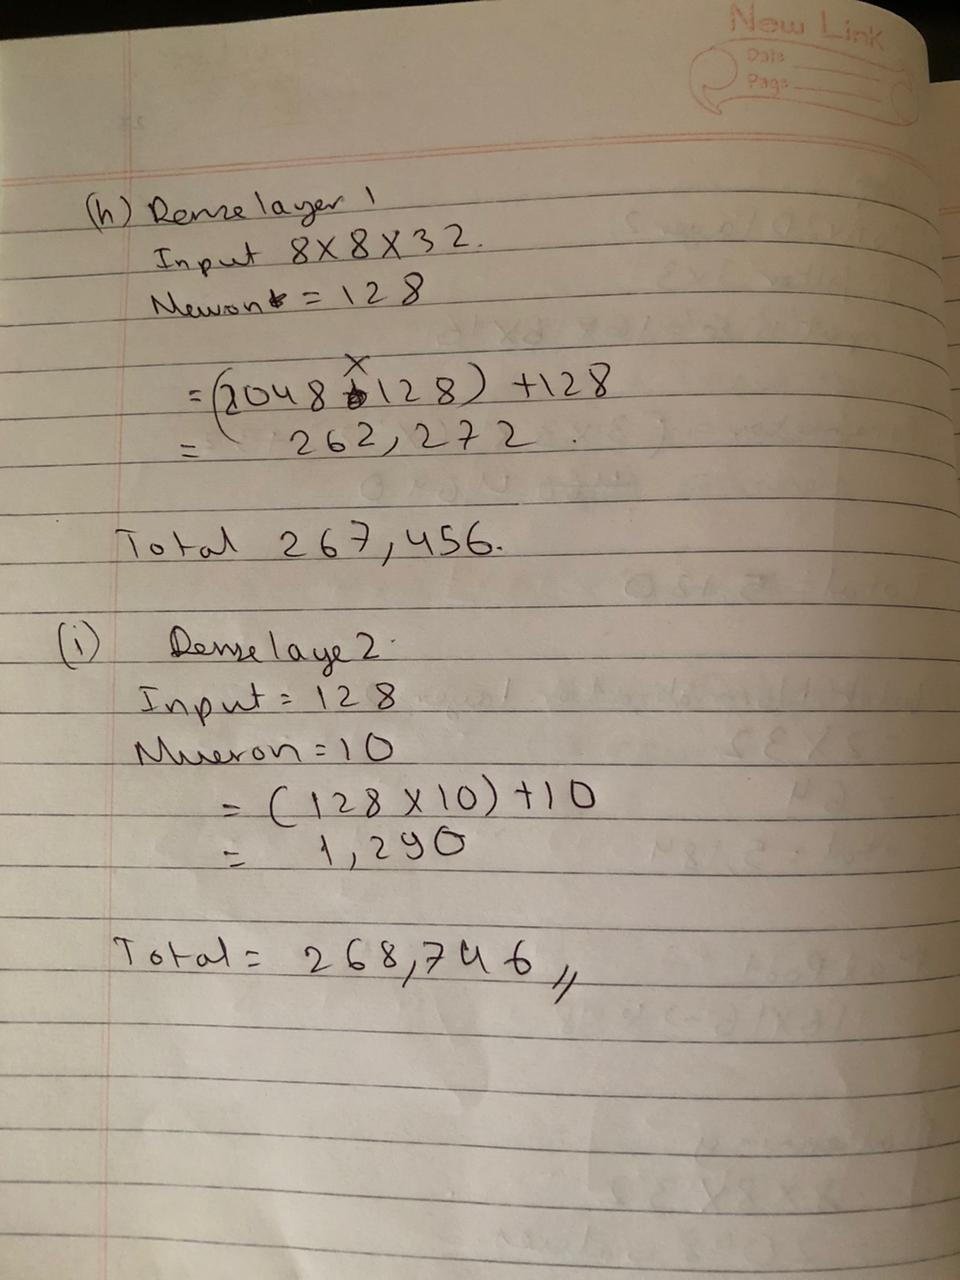

#Worksheet 6


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import zipfile, os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, Dropout, Flatten, Dense,
                                     GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report

zip_path  = '/content/drive/MyDrive/AI and ML/Copy of FruitinAmazon.zip'
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('./')

train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'
print("Extraction complete.")
print("Train:", os.listdir(train_dir))


Extraction complete.
Train: ['tucuma', 'pupunha', 'guarana', 'graviola', 'cupuacu', 'acai']


## Section 2.1 – Data Understanding and Visualizations

### Step 1 – Read dataset directory & extract class names

In [5]:
class_names = sorted(os.listdir(train_dir))
if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


### Step 2 – Check for corrupted images

In [6]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")


No corrupted images found.


### Step 3 – Check class balance

In [34]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print()
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print()
for cls, cnt in class_counts.items():
    print(f"{cls:<25}{cnt:>15}")
print()



Class Distribution:

Class Name               Valid Image Count

acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15



### Step 4 – Visualise one random image per class

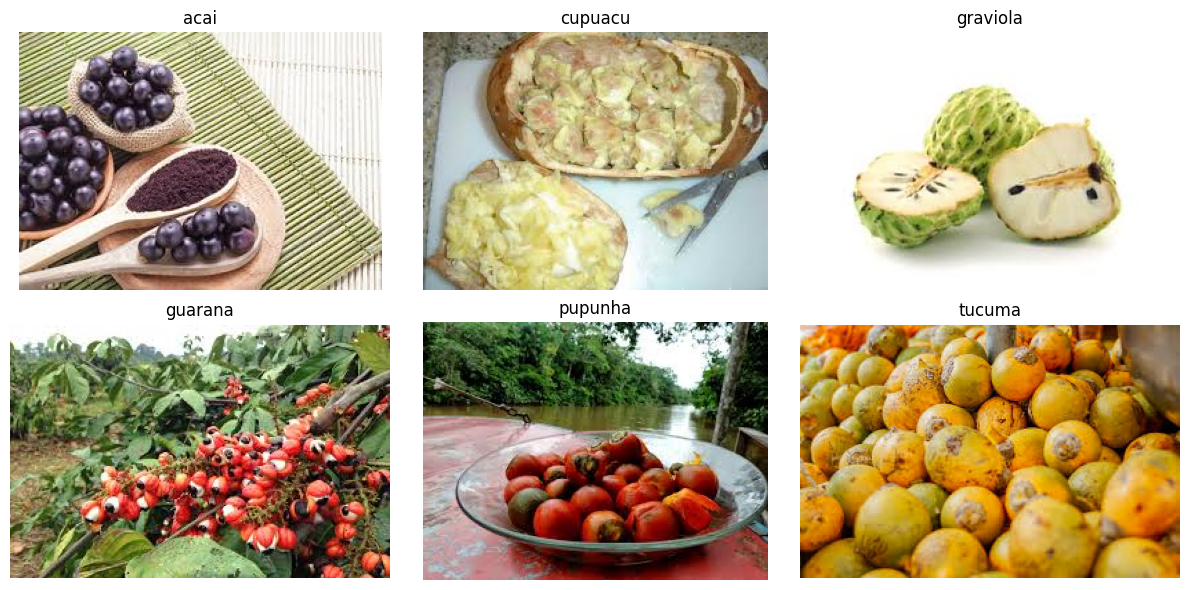

In [8]:
selected_images, selected_labels = [], []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_images.append(os.path.join(class_path, random.choice(images)))
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")
plt.tight_layout()
plt.show()


## Section 2.2 – Data Generation and Pre-processing

### Step 1 – Load train/val datasets


In [9]:
IMAGE_SIZE  = (128, 128)
BATCH_SIZE  = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Inspect a batch
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)


Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Images shape: (32, 128, 128, 3)
Labels shape: (32,)


### Step 2 – Visualise a batch from train_ds

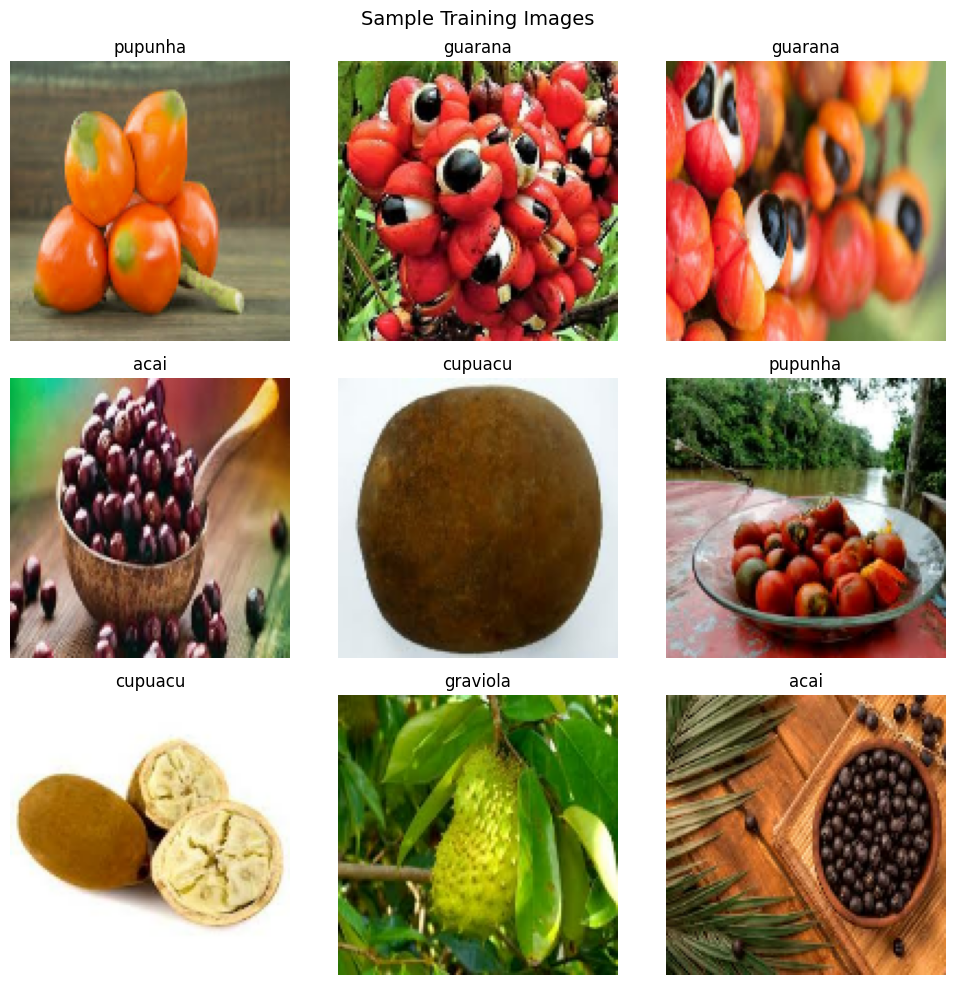

In [10]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


### Step 3 – Define data augmentation

In [11]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images


### Step 4 – Visualise augmented images

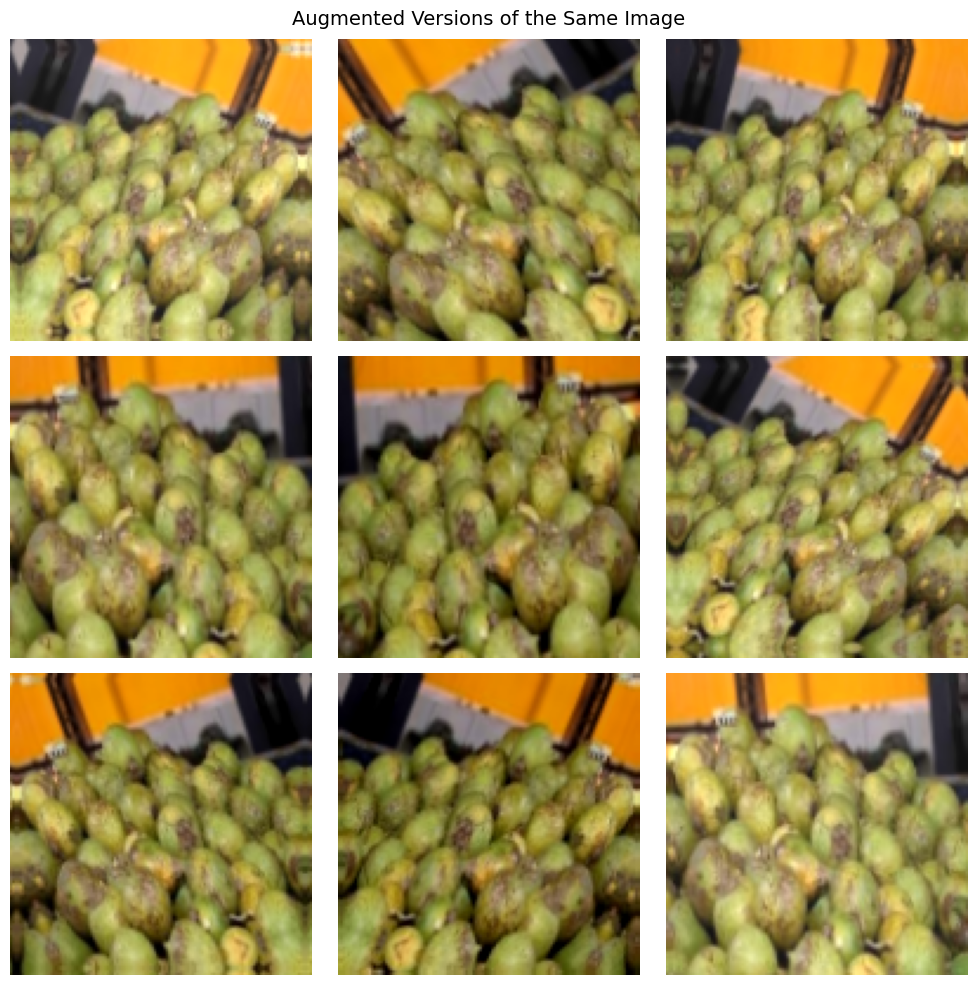

In [12]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented[0]).astype("uint8"))
        plt.axis("off")
plt.suptitle("Augmented Versions of the Same Image", fontsize=14)
plt.tight_layout()
plt.show()


## Task 1 – Improved CNN with BatchNormalization & Dropout
- Data Augmentation
- Deeper architecture
- BatchNormalization after every Conv / Dense block
- Dropout for regularisation


### Build the model

In [13]:
input_shape = (128, 128, 3)
num_classes = len(class_names)   # 6 fruit classes

inputs = keras.Input(shape=input_shape)

x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(x)

x = Conv2D(32, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

x = Conv2D(128, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

x = Conv2D(256, (3, 3), padding='same', activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)

x = Flatten()(x)

x = Dense(512, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(256, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation=None)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model_scratch = keras.Model(inputs=inputs, outputs=outputs, name="CNN_from_scratch")
model_scratch.summary()


Model: "CNN_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 128, 128, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,948,038 (34.13 MB)

 Trainable params: 8,945,286 (34.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

### Compile the model

In [14]:
model_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


### Load test dataset

In [15]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123
)


Found 30 files belonging to 6 classes.


### Train the model

In [16]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'best_scratch_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True,
    verbose=1
)

history_scratch = model_scratch.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb]
)


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.1551 - loss: 2.4456
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_scratch_model.keras

Epoch 1: finished saving model to best_scratch_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1528 - loss: 2.4261 - val_accuracy: 0.1111 - val_loss: 1.8233
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 795ms/step - accuracy: 0.3171 - loss: 2.2488
Epoch 2: val_accuracy did not improve from 0.11111
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 885ms/step - accuracy: 0.2639 - loss: 2.3544 - val_accuracy: 0.1111 - val_loss: 1.8128
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 833ms/step - accuracy: 0.1846 - loss: 2.2686
Epoch 3: val_accuracy did not improve from 0.11111
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 995ms/step - accuracy: 0.1944 - loss: 2.1988 - val_accuracy: 0.0556 - val_loss: 1.8140
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.2951 - loss: 2.1329
Epoch 4: val_accuracy did not improve from 0.11111
3/3 ━━━━━━━

### Plot training curves

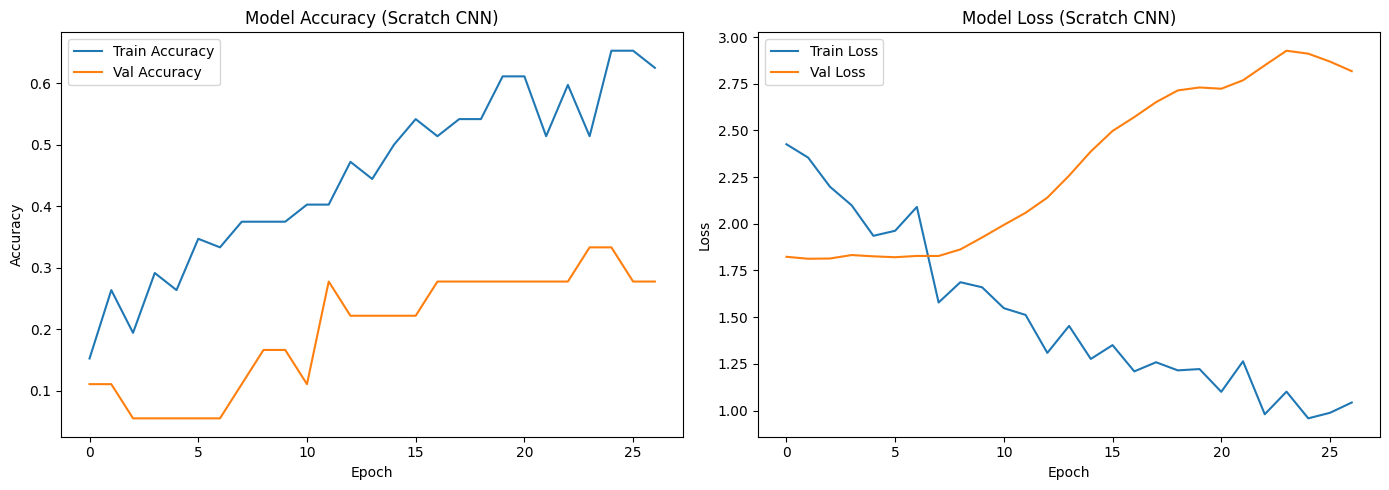

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_scratch.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy (Scratch CNN)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_scratch.history['loss'],     label='Train Loss')
axes[1].plot(history_scratch.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss (Scratch CNN)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluate on test set

In [18]:
test_loss, test_acc = model_scratch.evaluate(test_ds)
print(f"Scratch CNN  –  Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.1667 - loss: 1.7810
Scratch CNN  –  Test Loss: 1.7810  |  Test Accuracy: 0.1667


### Save the scratch model

In [19]:
model_scratch.save('cnn_scratch_ws6.keras')
print("Scratch model saved as cnn_scratch_ws6.keras")


Scratch model saved as cnn_scratch_ws6.keras


### Classification report – scratch CNN

In [20]:
y_true_s, y_pred_s = [], []
for images, labels in test_ds:
    preds = model_scratch.predict(images, verbose=0)
    y_pred_s.extend(np.argmax(preds, axis=1))
    y_true_s.extend(labels.numpy())

print("Classification Report – Scratch CNN")
print(classification_report(y_true_s, y_pred_s, target_names=class_names))


Classification Report – Scratch CNN
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.15      0.80      0.25         5
     guarana       0.00      0.00      0.00         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.17        30
   macro avg       0.19      0.17      0.10        30
weighted avg       0.19      0.17      0.10        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Task 2 – Transfer Learning with VGG16



### Step 1 – Prepare datasets for VGG16

In [21]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def preprocess_vgg(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)   # VGG16-specific normalisation
    return image, label

train_ds_vgg = train_ds.map(preprocess_vgg)
val_ds_vgg   = val_ds.map(preprocess_vgg)
test_ds_vgg  = test_ds.map(preprocess_vgg)


### Step 2 – Load VGG16 base (no top, frozen)

In [22]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Freeze all base layers
for layer in base_model.layers:
    layer.trainable = False

print(f"VGG16 base layers: {len(base_model.layers)}")
print(f"Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}")
base_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base layers: 19
Trainable layers : 0


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 3 – Add custom classification head

In [23]:
x = base_model.output
x = GlobalAveragePooling2D()(x)          # reduces (7,7,512) → (512,)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs_vgg = Dense(num_classes, activation='softmax')(x)

model_vgg = Model(inputs=base_model.input, outputs=outputs_vgg, name="VGG16_TransferLearning")
model_vgg.summary()


Model: "VGG16_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,503,942 (59.14 MB)

 Trainable params: 789,254 (3.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Step 4 – Compile

In [24]:
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


### Step 5 – Train (only the custom head layers update; VGG16 base is frozen)

In [25]:
checkpoint_vgg = keras.callbacks.ModelCheckpoint(
    'best_vgg16_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_vgg = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_vgg = model_vgg.fit(
    train_ds_vgg,
    epochs=30,
    validation_data=val_ds_vgg,
    callbacks=[checkpoint_vgg, early_stop_vgg]
)


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1105 - loss: 13.3301
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_vgg16_model.keras

Epoch 1: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.0972 - loss: 12.9035 - val_accuracy: 0.1111 - val_loss: 7.3598
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2043 - loss: 11.1021
Epoch 2: val_accuracy improved from 0.11111 to 0.22222, saving model to best_vgg16_model.keras

Epoch 2: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step - accuracy: 0.2222 - loss: 10.2644 - val_accuracy: 0.2222 - val_loss: 5.6591
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2350 - loss: 7.6767
Epoch 3: val_accuracy improved from 0.22222 to 0.27778, saving model to best_vgg16_model.keras

Epoch 3: finished saving model to best_vgg16_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - accuracy: 0.2361 - loss: 7.4887 

### Plot VGG16 training curves

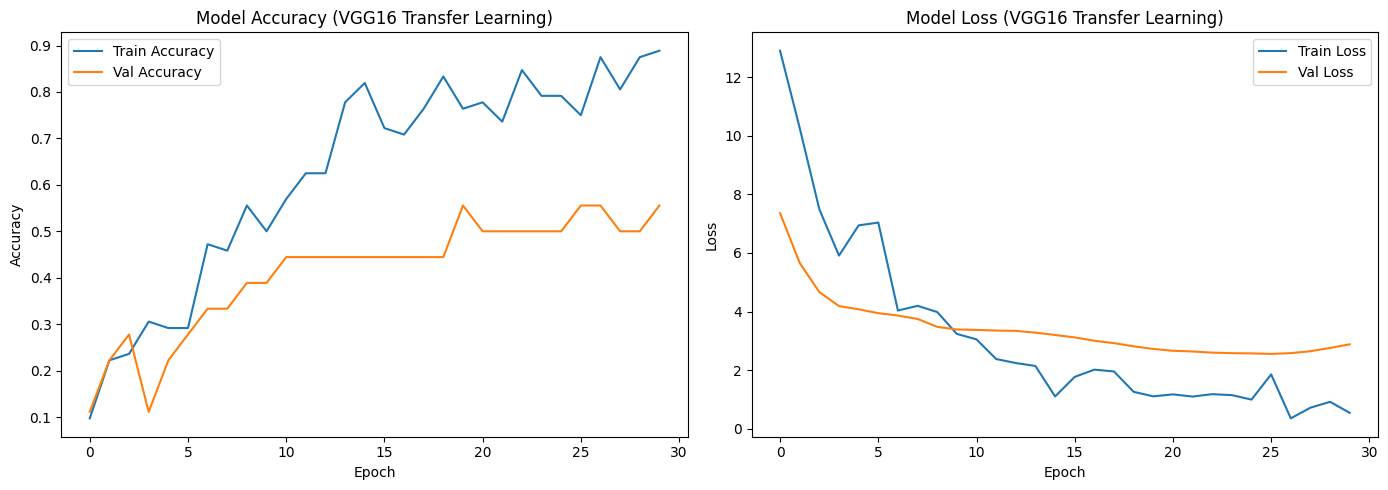

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy (VGG16 Transfer Learning)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_vgg.history['loss'],     label='Train Loss')
axes[1].plot(history_vgg.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss (VGG16 Transfer Learning)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


### Evaluate VGG16 on test set

In [27]:
vgg_loss, vgg_acc = model_vgg.evaluate(test_ds_vgg)
print(f"VGG16 Transfer  –  Test Loss: {vgg_loss:.4f}  |  Test Accuracy: {vgg_acc:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.8000 - loss: 1.7679
VGG16 Transfer  –  Test Loss: 1.7679  |  Test Accuracy: 0.8000


### Inference output – predicted vs actual labels

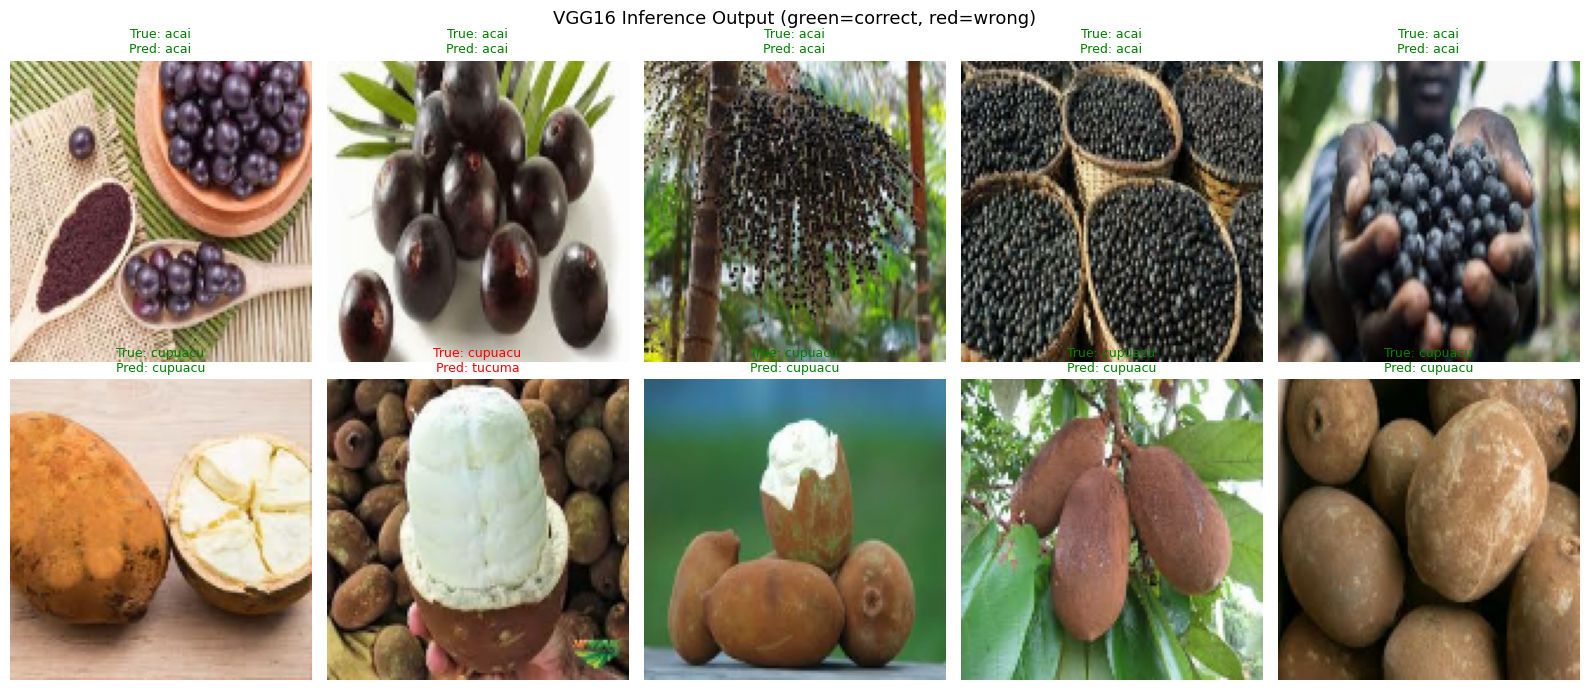

In [28]:
# Show a sample batch with predictions
for images_raw, labels in test_ds.take(1):
    images_proc, _ = preprocess_vgg(images_raw, labels)
    preds = model_vgg.predict(images_proc, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, ax in enumerate(axes.flat):
        if i < len(images_raw):
            ax.imshow(images_raw[i].numpy().astype("uint8"))
            true_cls = class_names[labels[i]]
            pred_cls = class_names[pred_labels[i]]
            color    = 'green' if true_cls == pred_cls else 'red'
            ax.set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=9)
            ax.axis('off')
    plt.suptitle("VGG16 Inference Output (green=correct, red=wrong)", fontsize=13)
    plt.tight_layout()
    plt.show()


### Classification report – VGG16

In [29]:
y_true_v, y_pred_v = [], []
for images, labels in test_ds_vgg:
    preds = model_vgg.predict(images, verbose=0)
    y_pred_v.extend(np.argmax(preds, axis=1))
    y_true_v.extend(labels.numpy())

print("Classification Report – VGG16 Transfer Learning")
print(classification_report(y_true_v, y_pred_v, target_names=class_names))


Classification Report – VGG16 Transfer Learning
              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       1.00      0.80      0.89         5
    graviola       1.00      0.80      0.89         5
     guarana       0.71      1.00      0.83         5
     pupunha       1.00      0.60      0.75         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.80        30
   macro avg       0.84      0.80      0.80        30
weighted avg       0.84      0.80      0.80        30



### Save VGG16 model

In [30]:
model_vgg.save('vgg16_transfer_ws6.keras')
print("VGG16 model saved as vgg16_transfer_ws6.keras")


VGG16 model saved as vgg16_transfer_ws6.keras


## Comparison – Scratch CNN vs VGG16 Transfer Learning

In [33]:
print()
print(f"{'Model':<30} {'Test Accuracy':>12} {'Test Loss':>10}")
print()
print(f"{'Scratch CNN (Worksheet-6)':<30} {test_acc:>12.4f} {test_loss:>10.4f}")
print(f"{'VGG16 Transfer Learning':<30} {vgg_acc:>12.4f} {vgg_loss:>10.4f}")
print()

improvement = (vgg_acc - test_acc) * 100
print(improvement)



Model                          Test Accuracy  Test Loss

Scratch CNN (Worksheet-6)            0.1667     1.7810
VGG16 Transfer Learning              0.8000     1.7679

63.333334028720856


Task 1 scratched CNN from scratch never had a real shot. With only 72 training images and no pretrained weights, the model had nothing to work with. Early stopping kicked in at epoch 27, and the best checkpoint (from epoch 2) just predicted "tucuma" for everything. That 16.7% accuracy is basically random guessing.

Task 2 went much better. VGG16 got 24 out of 30 right (80%), which is solid for a 15-image-per-class dataset. Guarana was perfect. Cupuacu was the weak spot, with only 2 of 5 recalled, probably because it looks similar to acai and there just wasn't enough data to tell them apart.

The takeaway is simple: you cannot train a vision model from nothing on 15 images per class. VGG16 already knows what edges, textures, and shapes look like from ImageNet. The custom head just needs to figure out which fruit is which, not relearn vision from zero.